# Visa for Lisa

The project is about a fictional bank called Galaxy Bank. 

The bank has had some previous success in upselling to its deposit clients. Still, unfortunately, not all clients offered a loan by Galaxy Bank accept it and become a loan customers.

The goal is to help Galaxy Bank improve its marketing conversion rates by allowing them to target and predict which of their deposit clients are most likely to accept a loan offer from the bank. You will be meeting with the marketing leadership at the bank.

The dataset is quite clean. The problem seems to be a binary classification, however, the requirement is to use linear regression. That's why I am going to implement thresholding.

Dataset dictionary:</br>
`ID`: Customer ID</br>
`Age`: Customer's age in completed years </br>
`Experience`: #years of professional experience </br>
`Income`: Annual income of the customer (\$000) </br>
`ZIP Code`: Home Address ZIP code.</br>
`Family`: Family size of the customer</br>
`CCAvg`: Avg. spending on credit cards per month (\$000)</br>
`Education`: Education Level.</br>
&nbsp;&nbsp;&nbsp;&nbsp;1: Undergrad;</br>
&nbsp;&nbsp;&nbsp;&nbsp;2: Graduate;</br>
&nbsp;&nbsp;&nbsp;&nbsp;3: Advanced/Professional.</br>
`Mortgage`: Value of house mortgage if any. ($000)</br>
`Personal Loan`: Did this customer accept the personal loan offered in the last campaign? - Target column</br>
`Securities Account`: Does the customer have a securities account with the bank?</br>
`CD Account`: Does the customer have a certificate of deposit (CD) account with the bank?</br>
`Online`: Does the customer use internet banking facilities?</br>
`Credit card`: Does the customer use a credit card issued by</br>


Dataset: https://www.kaggle.com/code/krantiswalke/bank-personal-loan-modelling-supervised-learning/input

## Table of contents:
* [Imports](#imports)
* [Data Loading](#data-loading)
* [Data Exploration](#data-exploration)
* [Data Cleaning](#data-cleaning)
* [Feature Engineering](#feature-engineering)
* [Model Training](#model-training)
* [Model Analysis](#model-analysis)
* [Hyperparameter Optimization](#optimization)

## Imports <a class="anchor" id="imports"></a>

In [119]:
import optuna
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.ml.regression import LinearRegression, GeneralizedLinearRegression, DecisionTreeRegressor, RandomForestRegressor, GBTRegressor
from pyspark.ml.classification import DecisionTreeClassifier, RandomForestClassifier
from pyspark.ml.feature import VectorAssembler, Tokenizer, HashingTF, IDF
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.sql.functions import when, log1p, mean, col

In [2]:
import os
os.environ["JAVA_HOME"] = "/opt/homebrew/Cellar/openjdk@17/17.0.16/libexec/openjdk.jdk/Contents/Home"
os.environ["SHELL"] = "/bin/bash"
os.environ["PATH"] = (
    os.path.join(os.environ["JAVA_HOME"], "bin") +
    ":/usr/local/bin:/usr/bin:/bin:/usr/sbin:/sbin"
)


In [3]:
spark = SparkSession \
    .builder \
    .appName("Visa for Lisa") \
    .getOrCreate()

spark.conf.set("spark.sql.debug.maxToStringFields", 1000)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/09/10 10:59:06 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## Data Loading <a class="anchor" id="data-loading"></a>

In [4]:
df = spark.read \
    .option("header", True) \
    .csv("Visa_For_Lisa_Loan_Modelling.csv", inferSchema=True)

In [5]:
df.show()

+---+---+----------+------+--------+------+-----+---------+--------+-------------+------------------+----------+------+----------+
| ID|Age|Experience|Income|ZIP Code|Family|CCAvg|Education|Mortgage|Personal Loan|Securities Account|CD Account|Online|CreditCard|
+---+---+----------+------+--------+------+-----+---------+--------+-------------+------------------+----------+------+----------+
|  1| 25|         1|    49|   91107|     4|  1.6|        1|       0|            0|                 1|         0|     0|         0|
|  2| 45|        19|    34|   90089|     3|  1.5|        1|       0|            0|                 1|         0|     0|         0|
|  3| 39|        15|    11|   94720|     1|  1.0|        1|       0|            0|                 0|         0|     0|         0|
|  4| 35|         9|   100|   94112|     1|  2.7|        2|       0|            0|                 0|         0|     0|         0|
|  5| 35|         8|    45|   91330|     4|  1.0|        2|       0|            0| 

In [6]:
df.printSchema()

root
 |-- ID: integer (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Experience: integer (nullable = true)
 |-- Income: integer (nullable = true)
 |-- ZIP Code: integer (nullable = true)
 |-- Family: integer (nullable = true)
 |-- CCAvg: double (nullable = true)
 |-- Education: integer (nullable = true)
 |-- Mortgage: integer (nullable = true)
 |-- Personal Loan: integer (nullable = true)
 |-- Securities Account: integer (nullable = true)
 |-- CD Account: integer (nullable = true)
 |-- Online: integer (nullable = true)
 |-- CreditCard: integer (nullable = true)



In [7]:
df.describe().toPandas()

,summary,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,count,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000
1,mean,2500.5,45.3384,20.1046,73.7742,93152.503,2.3964,1.9379380000000053,1.881,56.4988,0.096,0.1044,0.0604,0.5968,0.294
2,stddev,1443.5200033252052,11.463165630542662,11.46795368112056,46.03372932108627,2121.8521973361953,1.1476630455378507,1.7476589800467675,0.839869082664199,101.71380210211213,0.29462070577617994,0.30580932600032634,0.23825027311322794,0.4905893349626712,0.4556374886949281
3,min,1,23,-3,8,9307,1,0.0,1,0,0,0,0,0,0
4,max,5000,67,43,224,96651,4,10.0,3,635,1,1,1,1,1


In [8]:
df.groupBy("CD Account").count().show()

+----------+-----+
|CD Account|count|
+----------+-----+
|         1|  302|
|         0| 4698|
+----------+-----+



In [21]:
deposits = df.filter("`CD Account` = 1")

In [22]:
deposits.show()

+---+---+----------+------+--------+------+-----+---------+--------+-------------+------------------+----------+------+----------+
| ID|Age|Experience|Income|ZIP Code|Family|CCAvg|Education|Mortgage|Personal Loan|Securities Account|CD Account|Online|CreditCard|
+---+---+----------+------+--------+------+-----+---------+--------+-------------+------------------+----------+------+----------+
| 30| 38|        13|   119|   94104|     1|  3.3|        2|       0|            1|                 0|         1|     1|         1|
| 39| 42|        18|   141|   94114|     3|  5.0|        3|       0|            1|                 1|         1|     1|         0|
| 48| 37|        12|   194|   91380|     4|  0.2|        3|     211|            1|                 1|         1|     1|         1|
| 57| 55|        30|    29|   94005|     3|  0.1|        2|       0|            0|                 1|         1|     1|         0|
| 76| 31|         7|   135|   94901|     4|  3.8|        2|       0|            1| 

In [23]:
deposits.groupBy("Personal Loan").count().show()

+-------------+-----+
|Personal Loan|count|
+-------------+-----+
|            1|  140|
|            0|  162|
+-------------+-----+



## Data Exploration <a class="anchor" id="data-exploration"></a>

In [24]:
pd_deposits = deposits.toPandas()

<Axes: xlabel='Personal Loan'>

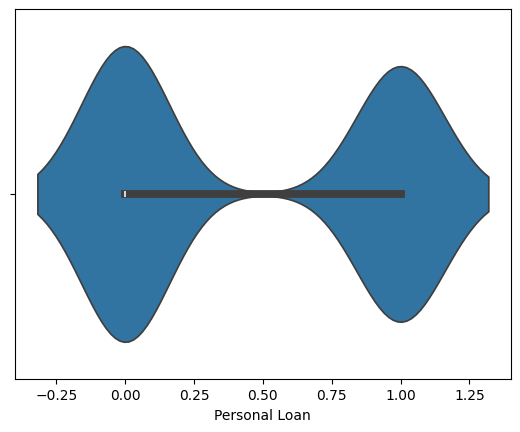

In [25]:
sns.violinplot(data=pd_deposits, x="Personal Loan")

From the above chart it can be clearly seen that the distribution of the target variable is almost equal.

<Axes: xlabel='Mortgage', ylabel='Count'>

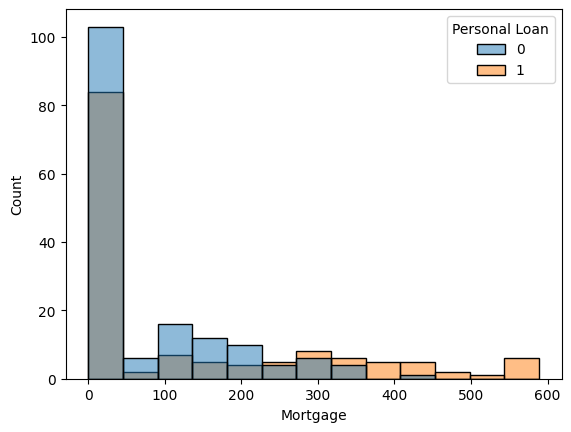

In [26]:
sns.histplot(data=pd_deposits, x="Mortgage", hue="Personal Loan")

It can be seen that there is a clear correlation between the size of the mortgage a client has got and whether they have accepted the personal loan offer. 
The higher the mortgage is the higher the chance of accepting the offer is.

<Axes: xlabel='Age', ylabel='Count'>

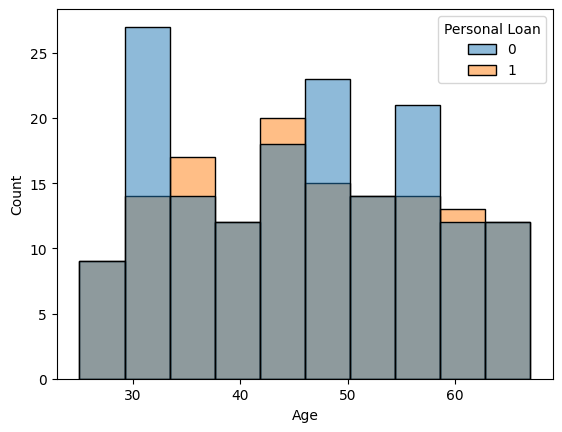

In [27]:
sns.histplot(data=pd_deposits, x="Age", hue="Personal Loan")

Interestingly, there is no correlation between the `Age` and the `Personal Loan`. Probably the data was balanced before.

<Axes: xlabel='Income', ylabel='Count'>

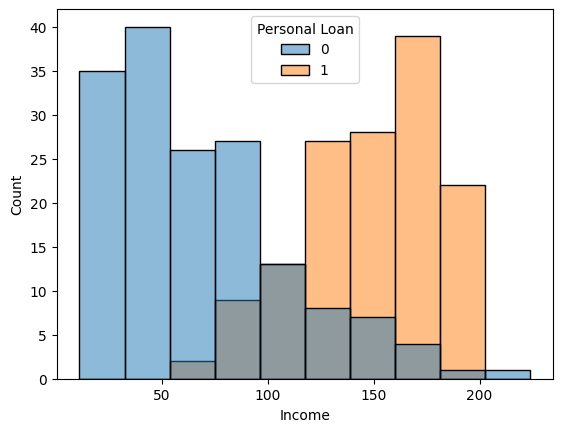

In [28]:
sns.histplot(data=pd_deposits, x="Income", hue="Personal Loan")

It is clear that the higher the `Income` is the higher the chance of accepting the `Personal Loan` offer.

sns.violinplot(data=pd_deposits, x="Personal Loan", y="CCAvg")

Here we see something that I would expect. The higher the credit card average is the higher the chance for acception the offer is.

## Data Cleaning <a class="anchor" id="data-cleaning"></a>

The data is quite clean, however some normalization should be implemented. I will use log to normalize `Income`, `CCAvg`, and `Mortgage` and target encoding for the high cardinality features.

In [35]:
deposits = deposits.withColumn("Income_log_norm", log1p("Income"))
deposits = deposits.withColumn("CCAvg_log_norm", log1p("CCAvg"))
deposits = deposits.withColumn("Mortgage_log_norm", log1p("Mortgage"))

In [37]:
deposits.select("Income_log_norm", "CCAvg_log_norm", "Mortgage_log_norm").show()

+------------------+-------------------+-----------------+
|   Income_log_norm|     CCAvg_log_norm|Mortgage_log_norm|
+------------------+-------------------+-----------------+
| 4.787491742782046| 1.4586150226995167|              0.0|
| 4.955827057601261|  1.791759469228055|              0.0|
| 5.272999558563747|0.18232155679395462|5.356586274672012|
|3.4011973816621555|0.09531017980432487|              0.0|
| 4.912654885736052| 1.5686159179138452|              0.0|
|5.0106352940962555| 2.1041341542702074|              0.0|
|3.7612001156935624| 0.9162907318741551|              0.0|
|  4.77912349311153| 2.1400661634962708|              0.0|
|3.1354942159291497| 0.6931471805599453|              0.0|
|5.0689042022202315| 1.8082887711792655|              0.0|
| 5.153291594497779|  1.410986973710262|5.645446897643238|
| 5.003946305945459| 2.1400661634962708|              0.0|
|3.9889840465642745| 1.0647107369924282| 4.59511985013459|
|  5.14166355650266|  2.186051276738094|4.60517018598809

In [43]:
te_features = ["Experience", "Family", "CreditCard", "Education", "Securities Account", "CD Account"]

df_encoded = deposits
for col in te_features:
    enc = (
        deposits.groupBy(col)
          .agg(mean("Personal Loan").alias(f"{col}_te"))
    )
    df_encoded = df_encoded.join(enc, on=col, how="left")

deposits = df_encoded
deposits.show()

+----------+------------------+---------+----------+------+----------+---+---+------+--------+-----+--------+-------------+------+------------------+-------------------+-----------------+-------------------+-------------------+------------------+------------------+---------------------+-------------------+
|CD Account|Securities Account|Education|CreditCard|Family|Experience| ID|Age|Income|ZIP Code|CCAvg|Mortgage|Personal Loan|Online|   Income_log_norm|     CCAvg_log_norm|Mortgage_log_norm|      Experience_te|          Family_te|     CreditCard_te|      Education_te|Securities Account_te|      CD Account_te|
+----------+------------------+---------+----------+------+----------+---+---+------+--------+-----+--------+-------------+------+------------------+-------------------+-----------------+-------------------+-------------------+------------------+------------------+---------------------+-------------------+
|         1|                 0|        2|         1|     1|        13| 30| 3

In [44]:
deposits.printSchema()

root
 |-- CD Account: integer (nullable = true)
 |-- Securities Account: integer (nullable = true)
 |-- Education: integer (nullable = true)
 |-- CreditCard: integer (nullable = true)
 |-- Family: integer (nullable = true)
 |-- Experience: integer (nullable = true)
 |-- ID: integer (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Income: integer (nullable = true)
 |-- ZIP Code: integer (nullable = true)
 |-- CCAvg: double (nullable = true)
 |-- Mortgage: integer (nullable = true)
 |-- Personal Loan: integer (nullable = true)
 |-- Online: integer (nullable = true)
 |-- Income_log_norm: double (nullable = true)
 |-- CCAvg_log_norm: double (nullable = true)
 |-- Mortgage_log_norm: double (nullable = true)
 |-- Experience_te: double (nullable = true)
 |-- Family_te: double (nullable = true)
 |-- CreditCard_te: double (nullable = true)
 |-- Education_te: double (nullable = true)
 |-- Securities Account_te: double (nullable = true)
 |-- CD Account_te: double (nullable = true)



## Feature Engineering <a class="anchor" id="feature-engineering"></a>

Now, let's implement some feature engineering to try help our model with the classification.

In [46]:
deposits = deposits.withColumn("Mortgage_to_Income", col("Mortgage") / col("Income"))
deposits = deposits.withColumn("Income_times_CCAvg", col("Income") * col("CCAvg"))
deposits = deposits.withColumn("Age_times_Experience", col("Age") * col("Experience"))

In [47]:
deposits.select("Mortgage_to_Income", "Income_times_CCAvg", "Age_times_Experience").show()

+------------------+------------------+--------------------+
|Mortgage_to_Income|Income_times_CCAvg|Age_times_Experience|
+------------------+------------------+--------------------+
|               0.0|             392.7|                 494|
|               0.0|             705.0|                 756|
|1.0876288659793814|38.800000000000004|                 444|
|               0.0|2.9000000000000004|                1650|
|               0.0|             513.0|                 217|
|               0.0|            1072.8|                1972|
|               0.0|              63.0|                2006|
|               0.0|             885.0|                1012|
|               0.0|              22.0|                2160|
|               0.0|             805.8|                 396|
|1.6395348837209303|             533.2|                2496|
|               0.0|            1110.0|                1081|
| 1.849056603773585|100.69999999999999|                1034|
|0.5823529411764706|    

## Model Training <a class="anchor" id="model-training"></a>

In [96]:
deposits.printSchema()

root
 |-- CD Account: integer (nullable = true)
 |-- Securities Account: integer (nullable = true)
 |-- Education: integer (nullable = true)
 |-- CreditCard: integer (nullable = true)
 |-- Family: integer (nullable = true)
 |-- Experience: integer (nullable = true)
 |-- ID: integer (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Income: integer (nullable = true)
 |-- ZIP Code: integer (nullable = true)
 |-- CCAvg: double (nullable = true)
 |-- Mortgage: integer (nullable = true)
 |-- Personal Loan: integer (nullable = true)
 |-- Online: integer (nullable = true)
 |-- Income_log_norm: double (nullable = true)
 |-- CCAvg_log_norm: double (nullable = true)
 |-- Mortgage_log_norm: double (nullable = true)
 |-- Experience_te: double (nullable = true)
 |-- Family_te: double (nullable = true)
 |-- CreditCard_te: double (nullable = true)
 |-- Education_te: double (nullable = true)
 |-- Securities Account_te: double (nullable = true)
 |-- CD Account_te: double (nullable = true)
 |-- 

In [175]:
feature_assembler = VectorAssembler(
    inputCols=[
        "Age", "Experience", "Income", "ZIP Code", "Family", "CCAvg", 
        "Education", "Mortgage", "Securities Account", "Online", "CreditCard",
        "Income_log_norm", "CCAvg_log_norm", "Mortgage_log_norm", "Experience_te",
        "Family_te", "CreditCard_te", "Education_te", "Securities Account_te", 
        "CD Account_te", 
        # "Mortgage_to_Income", 
        # "Income_times_CCAvg", 
        # "Age_times_Experience"
    ],
    outputCol="independent_features"
    )

In [176]:
dataset = feature_assembler.transform(deposits)

In [177]:
dataset = dataset.select(["ID", "Personal Loan", "independent_features"])
dataset.show()

+---+-------------+--------------------+
| ID|Personal Loan|independent_features|
+---+-------------+--------------------+
| 30|            1|[38.0,13.0,119.0,...|
| 39|            1|[42.0,18.0,141.0,...|
| 48|            1|[37.0,12.0,194.0,...|
| 57|            0|[55.0,30.0,29.0,9...|
| 76|            1|[31.0,7.0,135.0,9...|
|132|            1|[58.0,34.0,149.0,...|
|139|            0|[59.0,34.0,42.0,9...|
|151|            0|[46.0,22.0,118.0,...|
|154|            0|[60.0,36.0,22.0,9...|
|200|            1|[36.0,11.0,158.0,...|
|210|            1|[64.0,39.0,172.0,...|
|228|            0|[47.0,23.0,148.0,...|
|229|            0|[47.0,22.0,53.0,9...|
|244|            1|[65.0,39.0,170.0,...|
|248|            1|[53.0,29.0,120.0,...|
|263|            0|[49.0,23.0,33.0,9...|
|289|            1|[44.0,19.0,172.0,...|
|300|            1|[41.0,15.0,159.0,...|
|309|            0|[32.0,8.0,128.0,9...|
|323|            1|[63.0,39.0,101.0,...|
+---+-------------+--------------------+
only showing top

### Training multiple models for comparison

In [178]:
train_data, test_data = dataset.randomSplit([0.75, 0.25], seed=28)

In [156]:
algorithms = {
    "LinearRegression": LinearRegression(),
    "GeneralizedLinearRegression": GeneralizedLinearRegression(),
    "DecisionTreeRegressor": DecisionTreeRegressor(),
    "RandomForestRegressor": RandomForestRegressor(),
    "GBTRegressor": GBTRegressor(),
    "DecisionTreeClassifier": DecisionTreeClassifier(), 
    "RandomForestClassifier": RandomForestClassifier()
}

In [157]:
model_results = {}
for model, alg in algorithms.items():
    regressor = alg.setFeaturesCol("independent_features")
    regressor = alg.setLabelCol("Personal Loan")
    trained_model = regressor.fit(train_data)
    if "LinearRegression" in model:
        model_results[model] = trained_model.evaluate(test_data).predictions
    else: 
        model_results[model] = trained_model.transform(test_data)

25/09/10 12:22:48 WARN Instrumentation: [216be0c1] regParam is zero, which might cause numerical instability and overfitting.
25/09/10 12:22:48 WARN Instrumentation: [216be0c1] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
25/09/10 12:22:49 WARN Instrumentation: [0888294a] regParam is zero, which might cause numerical instability and overfitting.
25/09/10 12:22:49 WARN Instrumentation: [0888294a] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.


## Model Analysis <a class="anchor" id="model-analysis"></a>

In [158]:
def convert_to_class(predictions):
    return predictions.withColumn("prediction", when(predictions.prediction >= 0.5, 1.0).otherwise(0.0))

In [159]:
def compute_metrics(pred_results, model: str):
    predictions = convert_to_class(pred_results)
    
    accuracy = round(MulticlassClassificationEvaluator(
        labelCol="Personal Loan", predictionCol="prediction", metricName="accuracy"
    ).evaluate(predictions)*100, 2)
    
    precision = round(MulticlassClassificationEvaluator(
        labelCol="Personal Loan", predictionCol="prediction", metricName="precisionByLabel"
    ).evaluate(predictions)*100, 2)
    
    recall = round(MulticlassClassificationEvaluator(
        labelCol="Personal Loan", predictionCol="prediction", metricName="recallByLabel"
    ).evaluate(predictions)*100, 2)
    
    f1 = round(MulticlassClassificationEvaluator(
        labelCol="Personal Loan", predictionCol="prediction", metricName="f1"
    ).evaluate(predictions)*100, 2)

    return [(model, accuracy, precision, recall, f1)]


In [160]:
columns = ["Model", "Accuracy", "Precision", "Recall", "F1 Score"]

df = spark.createDataFrame([("N", 0.0, 0.0, 0.0, 0.0)], columns)
for model, preds in model_results.items():
    values = compute_metrics(preds, model)
    new_row = spark.createDataFrame(values, columns)
    df = df.union(new_row)

df = df.where("Model != 'N'")
df.show(truncate=False)

+---------------------------+--------+---------+------+--------+
|Model                      |Accuracy|Precision|Recall|F1 Score|
+---------------------------+--------+---------+------+--------+
|LinearRegression           |94.64   |100.0    |88.46 |94.61   |
|GeneralizedLinearRegression|94.64   |100.0    |88.46 |94.61   |
|DecisionTreeRegressor      |92.86   |100.0    |84.62 |92.78   |
|RandomForestRegressor      |96.43   |100.0    |92.31 |96.41   |
|GBTRegressor               |91.07   |100.0    |80.77 |90.94   |
|DecisionTreeClassifier     |92.86   |100.0    |84.62 |92.78   |
|RandomForestClassifier     |96.43   |100.0    |92.31 |96.41   |
+---------------------------+--------+---------+------+--------+



| Model                       | Accuracy | Precision | Recall | F1 Score | Iteration | Comments|
|-----------------------------|----------|-----------|--------|----------|-----------|---------|
|LinearRegression             |92.86     |89.29      |96.15   |92.87     |1          | Only the initial features are used. Without any normalization and feature engineering|
|GeneralizedLinearRegression  |92.86     |89.29      |96.15   |92.87     |1          ||
|DecisionTreeRegressor        |94.64     |100.0      |88.46   |94.61     |1          ||
|RandomForestRegressor        |92.86     |95.83      |88.46   |92.83     |1          ||
|GBTRegressor                 |94.64     |100.0      |88.46   |94.61     |1          ||
|DecisionTreeClassifier       |94.64     |100.0      |88.46   |94.61     |1          ||
|RandomForestClassifier       |96.43     |96.15      |96.15   |96.43     |1          ||
|                             |          |           |        |          |           ||
|LinearRegression             |94.64     |100.0      |88.46   |94.61     |2          | All features are used, including those from the normalizationa and feature engineering |
|GeneralizedLinearRegression  |94.64     |100.0      |88.46   |94.61     |2          ||
|DecisionTreeRegressor        |92.86     |100.0      |84.62   |92.78     |2          ||
|RandomForestRegressor        |96.43     |100.0      |92.31   |96.41     |2          ||
|GBTRegressor                 |91.07     |100.0      |80.77   |90.94     |2          ||
|DecisionTreeClassifier       |92.86     |100.0      |84.62   |92.78     |2          ||
|RandomForestClassifier       |94.64     |100.0      |88.46   |94.61     |2          ||
|                             |          |           |        |          |           ||
|LinearRegression             |94.64     |100.0      |88.46   |94.61     |3          | I have used only the all raw features and the normalized ones.|
|GeneralizedLinearRegression  |94.64     |100.0      |88.46   |94.61     |3          ||
|DecisionTreeRegressor        |94.64     |100.0      |88.46   |94.61     |3          ||
|RandomForestRegressor        |98.21     |100.0      |96.15   |98.21     |3          ||
|GBTRegressor                 |94.64     |100.0      |88.46   |94.61     |3          ||
|DecisionTreeClassifier       |94.64     |100.0      |88.46   |94.61     |3          ||
|RandomForestClassifier       |94.64     |100.0      |88.46   |94.61     |3          ||
|                             |          |           |        |          |           ||
|LinearRegression             |94.64     |96.0       |92.31   |94.63     |4          | I have used all raw features, the normalized ones and the `Mortgage_to_Income`.|
|GeneralizedLinearRegression  |94.64     |96.0       |92.31   |94.63     |4          ||
|DecisionTreeRegressor        |94.64     |100.0      |88.46   |94.61     |4          ||
|RandomForestRegressor        |96.43     |100.0      |92.31   |96.41     |4          ||
|GBTRegressor                 |94.64     |100.0      |88.46   |94.61     |4          ||
|DecisionTreeClassifier       |94.64     |100.0      |88.46   |94.61     |4          ||
|RandomForestClassifier       |96.43     |100.0      |92.31   |96.41     |4          ||
|                             |          |           |        |          |           ||
|LinearRegression             |94.64     |100.0      |88.46   |94.61     |5          | I have used all raw features, the normalized ones and the `Mortgage_to_Income` and `Income_times_CCAvg`.
|GeneralizedLinearRegression  |94.64     |100.0      |88.46   |94.61     |5          ||
|DecisionTreeRegressor        |92.86     |100.0      |84.62   |92.78     |5          ||
|RandomForestRegressor        |96.43     |100.0      |92.31   |96.41     |5          ||
|GBTRegressor                 |91.07     |100.0      |80.77   |90.94     |5          ||
|DecisionTreeClassifier       |92.86     |100.0      |84.62   |92.78     |5          ||
|RandomForestClassifier       |96.43     |100.0      |92.31   |96.41     |5          ||

- It can be clearly seen that the `RandomForestClassifier` is performing the best with the only raw data - `F1 Score - 96.43`.
- However, when we add all features it seems the `RandomForestRegressor` to perform the best in the second iteration but still worse than `RandomForestClassifier` from the first iteration.
- On the third iteration, where we train the model only on the raw features and the normalized ones it turns out that the `F1 Score` for the `RandomForestRegressor` is again the best for overall so far - `98.21`.
- After the fourth iteration, where I added the `Mortgage_to_Income` feature the `F1 Score` for the `RandomForestRegressor` is again the highest, however it is worse than the previous test.
- After adding `Mortgage_to_Income` and `Income_times_CCAvg` it turns out the `RandomForestRegressor` and `RandomForestClassifier` have the highest `F1 Score`, but the score from the third iteration of the `RandomForestRegressor` is still the highest among all the test.

<p style="font-size: 1.3em">In conclusion, the `RandomForestRegressor` performs the best and without the feature engineering but after the raw fields were normalized with an F1 Score of 98.21%. I believe, this score is high enough to say that the model performs really good. Now, let's try make it even better.</p>

## Hyperparameter Optimization <a class="anchor" id="optimization"></a>

I will do hyper parameter optimization on `Linear Regression` and `RandomForestRegressor` because I want to compare the baseline and the best performing model. I will optimize for `F1 Score` so to minimize errors and spend less money on wasted offers.

In [162]:
evaluator = MulticlassClassificationEvaluator(
    labelCol="Personal Loan",
    predictionCol="prediction",
    metricName="f1"
)

In [173]:
def objective_lr(trial):
    reg_param = trial.suggest_float("regParam", 0.0, 0.1)
    elastic_net = trial.suggest_float("elasticNetParam", 0.0, 1.0)
    lr = LinearRegression(
        featuresCol="independent_features",
        labelCol="Personal Loan",
        regParam=reg_param,
        elasticNetParam=elastic_net
    )
    model = lr.fit(train_data)
    predictions = model.transform(test_data)

    predictions_class = convert_to_class(predictions)

    f1_score = round(evaluator.evaluate(predictions_class)*100, 2)
    
    return f1_score

def objective_rfr(trial):
    num_trees = trial.suggest_int("numTrees", 10, 100)
    max_depth = trial.suggest_int("maxDepth", 2, 20)
    min_instances = trial.suggest_int("minInstancesPerNode", 1, 5)

    rf = RandomForestRegressor(
        featuresCol="independent_features",
        labelCol="Personal Loan",
        numTrees=num_trees,
        maxDepth=max_depth,
        minInstancesPerNode=min_instances
    )

    model = rf.fit(train_data)
    predictions = model.transform(test_data)

    predictions_class = convert_to_class(predictions)

    f1_score = evaluator.evaluate(predictions_class)
    return f1_score

In [179]:
# Linear Regression
study = optuna.create_study(direction="maximize")
study.optimize(objective_lr, n_trials=30)

print("Best params:", study.best_params)
print("Best Precision:", study.best_value)

[I 2025-09-10 12:37:59,665] A new study created in memory with name: no-name-02194eba-2b13-493d-945d-8ed617481224
[I 2025-09-10 12:38:00,128] Trial 0 finished with value: 94.61 and parameters: {'regParam': 0.017037146037933416, 'elasticNetParam': 0.08677276413497825}. Best is trial 0 with value: 94.61.
[I 2025-09-10 12:38:00,685] Trial 1 finished with value: 94.61 and parameters: {'regParam': 0.07479546484058468, 'elasticNetParam': 0.23885545304853695}. Best is trial 0 with value: 94.61.
[I 2025-09-10 12:38:01,071] Trial 2 finished with value: 96.41 and parameters: {'regParam': 0.05027484529256154, 'elasticNetParam': 0.9552045255560424}. Best is trial 2 with value: 96.41.
[I 2025-09-10 12:38:01,449] Trial 3 finished with value: 94.61 and parameters: {'regParam': 0.051744680022858196, 'elasticNetParam': 0.32726216646797124}. Best is trial 2 with value: 96.41.
[I 2025-09-10 12:38:01,863] Trial 4 finished with value: 96.41 and parameters: {'regParam': 0.05887046791064088, 'elasticNetParam

Best params: {'regParam': 0.05027484529256154, 'elasticNetParam': 0.9552045255560424}
Best Precision: 96.41


In [180]:
# RandomForestRegressor
study = optuna.create_study(direction="maximize")
study.optimize(objective_rfr, n_trials=30)

print("Best params:", study.best_params)
print("Best Precision:", study.best_value)

[I 2025-09-10 12:38:12,188] A new study created in memory with name: no-name-33f85814-02ee-4e59-8770-43d748774380
[I 2025-09-10 12:38:12,895] Trial 0 finished with value: 0.9641474654377881 and parameters: {'numTrees': 89, 'maxDepth': 4, 'minInstancesPerNode': 2}. Best is trial 0 with value: 0.9641474654377881.
[I 2025-09-10 12:38:13,746] Trial 1 finished with value: 0.9641474654377881 and parameters: {'numTrees': 89, 'maxDepth': 18, 'minInstancesPerNode': 3}. Best is trial 0 with value: 0.9641474654377881.
[I 2025-09-10 12:38:14,265] Trial 2 finished with value: 0.9641474654377881 and parameters: {'numTrees': 19, 'maxDepth': 6, 'minInstancesPerNode': 5}. Best is trial 0 with value: 0.9641474654377881.
[I 2025-09-10 12:38:15,082] Trial 3 finished with value: 0.9821141571382652 and parameters: {'numTrees': 87, 'maxDepth': 20, 'minInstancesPerNode': 1}. Best is trial 3 with value: 0.9821141571382652.
[I 2025-09-10 12:38:15,727] Trial 4 finished with value: 0.9821141571382652 and paramete

Best params: {'numTrees': 87, 'maxDepth': 20, 'minInstancesPerNode': 1}
Best Precision: 0.9821141571382652


<p style="font-size: 1.5em">In conclusion, I would suggest utilizing the RandomForestRegressor algorithm with the hyperparameters from the optimization session because it performed the best, thus the marketing costs will be lower and so the ROI will be higher.</p>